In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler

In [3]:
df = pd.read_csv(r"C:\ML dataset\Mall_Customers.csv")
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [4]:
df.isnull().sum()

CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

In [5]:
df.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


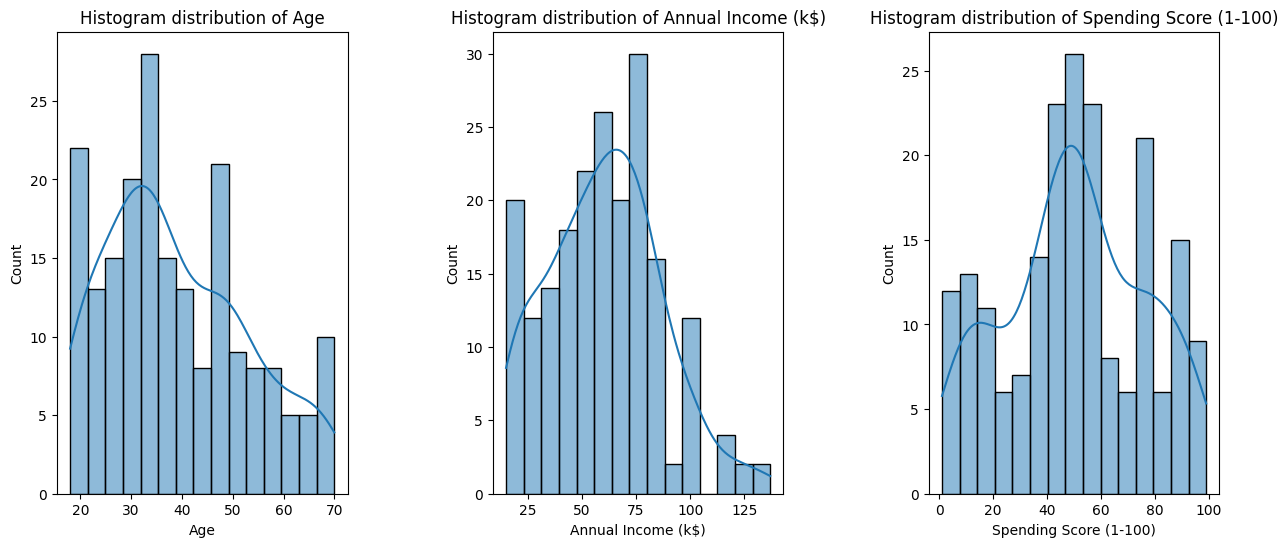

In [6]:
plt.figure(1, figsize=(15, 6))
i = 1
for x in ['Age', 'Annual Income (k$)', 'Spending Score (1-100)']:
    plt.subplot(1, 3, i)
    plt.subplots_adjust(hspace = 0.5, wspace = 0.5)
    sns.histplot(df[x], kde = True, bins = 15)
    plt.title("Histogram distribution of {}".format(x))
    # plt.title(f"Histogram distribution of {x}")
    i = i + 1

plt.show()

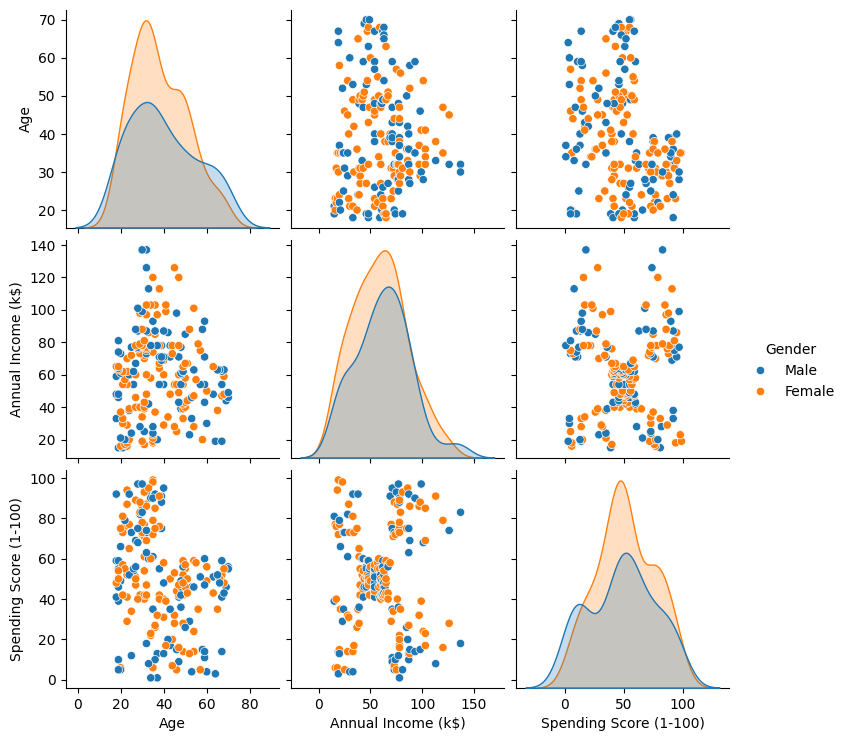

In [7]:
sns.pairplot(df, vars = ['Age', 'Annual Income (k$)', 'Spending Score (1-100)'], hue = 'Gender')

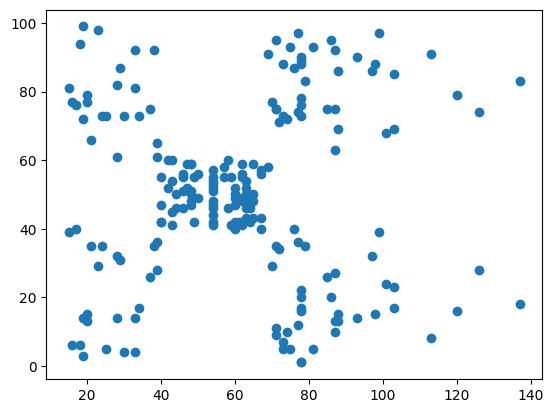

In [8]:
plt.scatter(df['Annual Income (k$)'], df['Spending Score (1-100)'])

In [22]:
x = df.drop(['CustomerID', 'Gender','Annual Income (k$)'], axis=1)
scaler = StandardScaler()
x_scaled = scaler.fit_transform(x)
k_range = range(2,15)
inertia = []
ss = []
for k in k_range:
    kmeans = KMeans(n_clusters=k,init='k-means++',max_iter=3000,n_init=10,tol=0.0001,algorithm='lloyd', random_state=42)
    kmeans.fit(x)
    labels = kmeans.predict(x)
    inertia.append(kmeans.inertia_)
    ss.append(silhouette_score(x, labels))



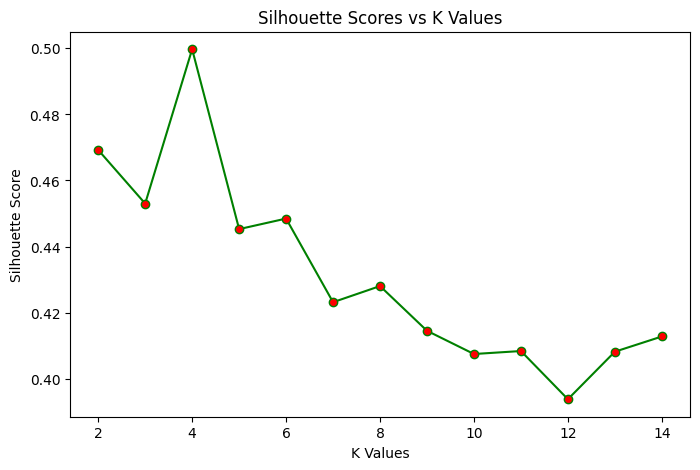

In [23]:

plt.figure(figsize=(8,5))

plt.plot(k_range, ss, marker='o', color='green', markerfacecolor='red')

plt.title("Silhouette Scores vs K Values")
plt.xlabel("K Values")
plt.ylabel("Silhouette Score")

plt.show()

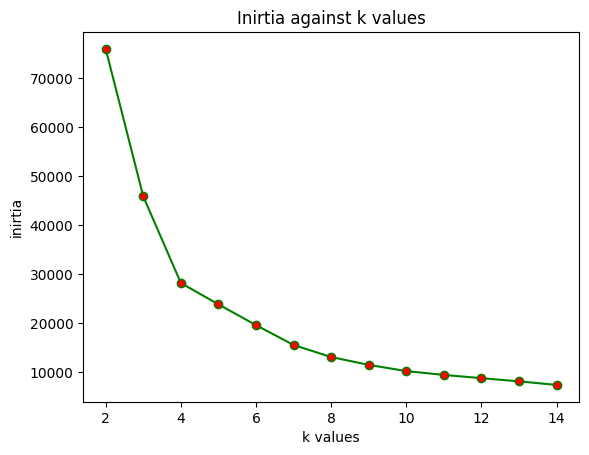

In [11]:
plt.plot(k_range, inertia, marker = 'o', color = 'green', markerfacecolor = 'red')
plt.title("Inirtia against k values")
plt.xlabel("k values")
plt.ylabel("inirtia")
plt.show()

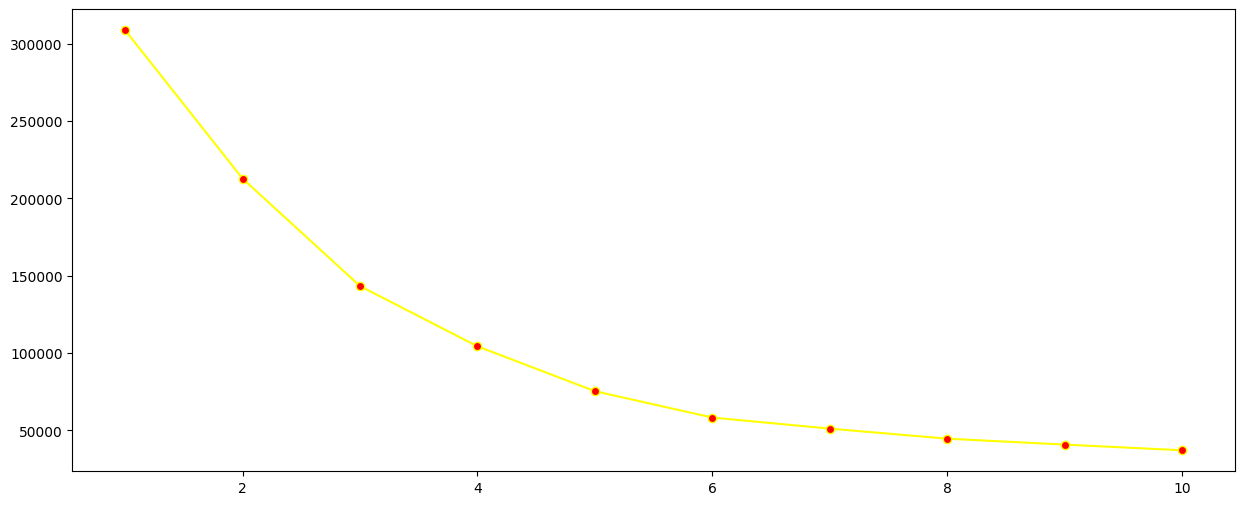

In [16]:
X3 = df[['Age', 'Annual Income (k$)', 'Spending Score (1-100)']].iloc[:, :].values
inertia = []
for n in range(1,11):
    algorithm = (KMeans(n_clusters=n, init='k-means++', max_iter=3000, n_init=10, tol=0.0001, algorithm='lloyd', random_state=42))
    algorithm.fit(X3)
    inertia.append(algorithm.inertia_)
plt.figure(1, figsize=(15,6))
plt.plot(np.arange(1, 11), inertia,marker= 'o', color = 'yellow', markerfacecolor = 'red')


Silhouette Scores
inertia

In [24]:
km = KMeans(n_clusters=5, init='k-means++', max_iter=3000, n_init=10, tol=0.0001, algorithm='lloyd', random_state=42)
km.fit(x_scaled)
labels = km.predict(x_scaled)
inertia = km.inertia_
ss = silhouette_score(x_scaled, labels)

print("Inertia: ", inertia)
print("silhouette_score: ", ss)

Inertia:  71.29556592219438
silhouette_score:  0.44754858878462783
